# Notebook 05 - Model Evaluation
## Fake News Detection - NLP Assignment
### Person 2: W.A. Irusha Madushan (CIT-24-01-0514)
### Evaluating: Random Forest (ML) + CNN (Deep Learning)

In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score,
                             confusion_matrix, roc_auc_score, 
                             roc_curve)

import tensorflow as tf
from tensorflow.keras.models import load_model

print("All libraries imported successfully")

All libraries imported successfully


## 1. Loading Models and Features

The trained Random Forest and CNN models are loaded along with 
the test data that was saved in Notebook 03. The same test set 
is used for both models to ensure a fair comparison.

In [2]:
# Load data
X_test_tfidf = sp.load_npz('../models/X_test_tfidf.npz')
X_test_pad = np.load('../models/X_test_pad.npy')
y_test = np.load('../models/y_test.npy')

# Load Random Forest model
with open('../models/rf_final_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)

# Load CNN model
cnn_model = load_model('../models/cnn_final_model.keras')

print("All models and features loaded successfully")
print("Test set size:", len(y_test))
print("Random Forest model loaded:", rf_model)
print("CNN model loaded:", cnn_model.name)

All models and features loaded successfully
Test set size: 14409
Random Forest model loaded: RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
CNN model loaded: sequential_7


## 2. Random Forest Model Evaluation

The Random Forest model is evaluated using five metrics:
- Accuracy: overall percentage of correct predictions
- Precision: out of all articles predicted as fake, how many 
  were actually fake
- Recall: out of all actual fake articles, how many did the 
  model correctly identify
- F1-Score: balanced average of precision and recall
- ROC-AUC: measures how well the model separates fake and 
  real news across all thresholds

In [3]:
# Random Forest predictions
rf_predictions = rf_model.predict(X_test_tfidf)
rf_probabilities = rf_model.predict_proba(X_test_tfidf)[:, 1]

# Calculate metrics
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_roc_auc = roc_auc_score(y_test, rf_probabilities)

print("=" * 45)
print("   Random Forest Evaluation Results")
print("=" * 45)
print(f"Accuracy:  {rf_accuracy * 100:.2f}%")
print(f"Precision: {rf_precision * 100:.2f}%")
print(f"Recall:    {rf_recall * 100:.2f}%")
print(f"F1-Score:  {rf_f1 * 100:.2f}%")
print(f"ROC-AUC:   {rf_roc_auc * 100:.2f}%")
print("=" * 45)

   Random Forest Evaluation Results
Accuracy:  95.53%
Precision: 94.89%
Recall:    96.50%
F1-Score:  95.69%
ROC-AUC:   99.28%


## 3. Random Forest Confusion Matrix

A confusion matrix shows the breakdown of correct and incorrect 
predictions in detail. It shows how many articles were correctly 
classified as fake or real, and how many were misclassified.

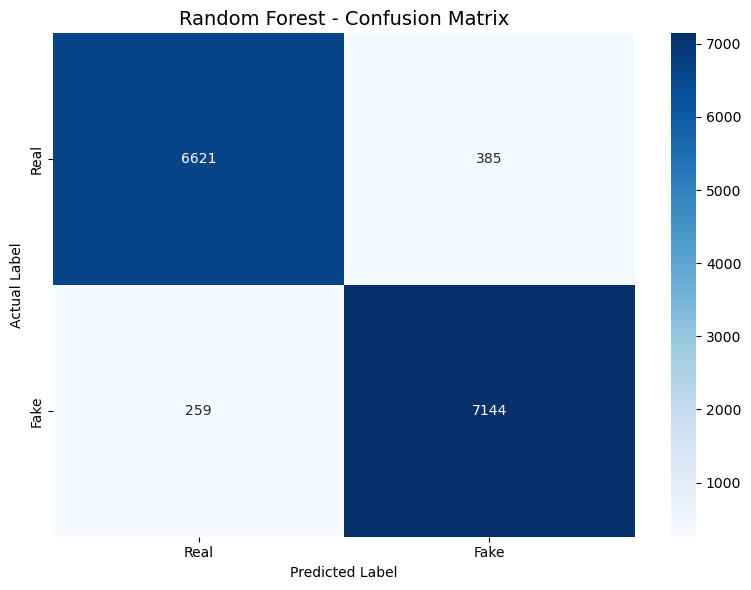

True Negatives  : 6621
False Positives  : 385
False Negatives  : 259
True Positives  : 7144


In [5]:
# Random Forest confusion matrix
rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title('Random Forest - Confusion Matrix', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../screenshots/rf_confusion_matrix.png', dpi=150)
plt.show()

# Print breakdown
tn, fp, fn, tp = rf_cm.ravel()
print(f"True Negatives  : {tn}")
print(f"False Positives  : {fp}")
print(f"False Negatives  : {fn}")
print(f"True Positives  : {tp}")